In [ ]:
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Audio processing
import librosa
import librosa.display
import torchaudio
import parselmouth
from parselmouth.praat import call
from pydub import AudioSegment
from scipy.io import wavfile
from scipy.signal import get_window, lfilter
from scipy import stats
from scipy.stats import skew, kurtosis, linregress
import scipy.fftpack as fft
import pywt  # Wavelet transform library
import IPython.display as ipd
from IPython.display import Audio

import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import numpy as np  
# Feature extraction
from spafe.features.lpc import lpcc

# Machine learning - Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, 
                               GradientBoostingClassifier, 
                               VotingClassifier, 
                               StackingClassifier)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
# ,adaboost
# Machine learning - Other libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# # Deep learning - TensorFlow
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Activation, Dropout
# from tensorflow.keras.utils import to_categorical

# Deep learning - PyTorch
import torch

# Visualization inline (for Jupyter notebooks)
%matplotlib inline


In [ ]:
df=pd.read_csv(r"C:\Users\apder\Downloads\EAED.csv")
df

In [3]:
df["Emotion"].value_counts()

Emotion
Neutral      1004
Angry         909
Sad           621
Surprised     447
Happy         428
Fearful       205
Name: count, dtype: int64

In [3]:
df2=pd.read_csv(r"C:\Users\apder\Downloads\EYASE_emotions.csv")
df2

,File Path,Emotion
0,C:\Users\apder\Downloads\EYASE\data\fm01_ang (...,Angry
1,C:\Users\apder\Downloads\EYASE\data\fm01_ang (...,Angry
2,C:\Users\apder\Downloads\EYASE\data\fm01_ang (...,Angry
3,C:\Users\apder\Downloads\EYASE\data\fm01_ang (...,Angry
4,C:\Users\apder\Downloads\EYASE\data\fm01_ang (...,Angry
...,...,...
574,C:\Users\apder\Downloads\EYASE\data\ml03_sad (...,Sad
575,C:\Users\apder\Downloads\EYASE\data\ml03_sad (...,Sad
576,C:\Users\apder\Downloads\EYASE\data\ml03_sad (...,Sad
577,C:\Users\apder\Downloads\EYASE\data\ml03_sad (...,Sad


In [4]:
df_combined = pd.concat([df, df2], ignore_index=True)
df_combined

,File Path,Emotion
0,C:\Users\apder\OneDrive\Desktop\EAED\Actor01_A...,Angry
1,C:\Users\apder\OneDrive\Desktop\EAED\Actor01_F...,Fearful
2,C:\Users\apder\OneDrive\Desktop\EAED\Actor01_F...,Fearful
3,C:\Users\apder\OneDrive\Desktop\EAED\Actor01_H...,Happy
4,C:\Users\apder\OneDrive\Desktop\EAED\Actor01_H...,Happy
...,...,...
4188,C:\Users\apder\Downloads\EYASE\data\ml03_sad (...,Sad
4189,C:\Users\apder\Downloads\EYASE\data\ml03_sad (...,Sad
4190,C:\Users\apder\Downloads\EYASE\data\ml03_sad (...,Sad
4191,C:\Users\apder\Downloads\EYASE\data\ml03_sad (...,Sad


In [5]:
total_duration = 0
for file_path in df_combined["File Path"]:
  y, sr = librosa.load(file_path, sr=None)
  total_duration += librosa.get_duration(y=y, sr=sr)

print(f"Total duration of all audio files in df_combined: {total_duration:.2f} seconds")

Total duration of all audio files in df_combined: 10296.90 seconds


#### Play the first audio file with emotion "Happy"


In [ ]:
file_path = df_combined[df_combined["Emotion"] == "Angry"]["File Path"].iloc[1000]
Audio(file_path, autoplay=True)

In [ ]:
# Plot the waveform of a sample from each emotion class in df_combined, with a unique color for each class
unique_emotions = df_combined["Emotion"].unique()
emotion_colors = {
  'Angry': 'red',
  'Fearful': 'purple',
  'Happy': 'orange',
  'Neutral': 'gray',
  'Surprised': 'blue',
  'Sad': 'green'
}

plt.figure(figsize=(15, 5 * len(unique_emotions)))

for idx, emotion in enumerate(unique_emotions):
  file_path = df_combined[df_combined["Emotion"] == emotion]["File Path"].iloc[0]
  signal, sr = librosa.load(file_path, sr=16000)
  plt.subplot(len(unique_emotions), 1, idx + 1)
  color = emotion_colors.get(emotion, None)
  librosa.display.waveshow(signal, sr=sr, color=color)
  plt.title(f"Waveform for Emotion: {emotion}", color=color)
  plt.xlabel("Time (s)")
  plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

#### Dropping empty files

In [ ]:
empty_indices = []

for index, i in enumerate(df_combined["File Path"]):
  data, sr = librosa.load(i)
  if len(data) == 0:
    print(f"Deleting file {i} because it is empty.")
    empty_indices.append(index)  # Collecting the index of the empty file

df_combined = df_combined.drop(index=empty_indices).reset_index(drop=True)


#### Total processed minutes

In [66]:
sum=0
for i in df_combined["File Path"]:
  y,sr=librosa.load(i)
  duration=librosa.get_duration(y=y)   
  sum+=duration
  
sum
   

10296.927936507956

#### Mapping Emotions

In [ ]:
df_combined["Emotion"] = df_combined["Emotion"].replace({
  "Angry": 1,
  "Fearful": 5,
  "Happy": 3,
  "Sad": 2,
  "Surprised": 4,
  "Neutral": 0
})

#### Data Augmentation

In [5]:
# Additive Noise Augmentation
def noise(data, snr_low=10, snr_high=25):
    # Generate random noise
    noise_signal = np.random.normal(size=data.shape)

    # Normalize signal and noise
    norm_constant = 2.0**15  # Equivalent to 16-bit PCM
    signal_norm = data / norm_constant
    noise_norm = noise_signal / norm_constant

    # Compute signal power
    signal_power = np.mean(signal_norm ** 2)

    # Random SNR in range (lower SNR = more noise)
    target_snr = np.random.randint(snr_low, snr_high)

    # Compute noise power
    noise_power = np.mean(noise_norm ** 2)

    # Scale factor for desired SNR
    scaling_factor = np.sqrt(signal_power / (noise_power * 10**(target_snr / 10)))

    # Scale and add noise
    scaled_noise = noise_signal * scaling_factor
    noisy_signal = data + scaled_noise

    return noisy_signal


# Time Stretching Augmentation
def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)

# Time Shifting Augmentation
def shift(data):
    shift_range = int(np.random.uniform(low=-5, high=5) * 1000)
    return np.roll(data, shift_range)

# Pitch Shifting Augmentation
def pitch(data, sampling_rate, pitch_factor=2.7):
    return librosa.effects.pitch_shift(y=data, sr=sampling_rate, n_steps=pitch_factor)

def time_masking(data, sampling_rate, mask_width=20, mask_count=2):
    # Compute STFT
    original_length = len(data)
    stft = librosa.stft(data)
    magnitude, phase = librosa.magphase(stft)

    num_time_frames = magnitude.shape[1]
    for _ in range(mask_count):
        start = np.random.randint(0, max(1, num_time_frames - mask_width))
        magnitude[:, start:start + mask_width] = 0

    masked_stft = magnitude * phase
    masked_audio = librosa.istft(masked_stft)

    # Match original length
    if len(masked_audio) > original_length:
        masked_audio = masked_audio[:original_length]
    elif len(masked_audio) < original_length:
        masked_audio = np.pad(masked_audio, (0, original_length - len(masked_audio)))

    return masked_audio


def frequency_masking(data, sampling_rate, mask_width=10, mask_count=2):
    # Compute STFT
    original_length = len(data)
    stft = librosa.stft(data)
    magnitude, phase = librosa.magphase(stft)

    num_freq_bins = magnitude.shape[0]
    for _ in range(mask_count):
        start = np.random.randint(0, max(1, num_freq_bins - mask_width))
        magnitude[start:start + mask_width, :] = 0

    masked_stft = magnitude * phase
    masked_audio = librosa.istft(masked_stft)

    # Match original length
    if len(masked_audio) > original_length:
        masked_audio = masked_audio[:original_length]
    elif len(masked_audio) < original_length:
        masked_audio = np.pad(masked_audio, (0, original_length - len(masked_audio)))

    return masked_audio
  

#### Visualizing the effect of data augmentation on an audio signal


In [ ]:
# Select a sample audio file from df_combined
sample_path = df_combined["File Path"].iloc[0]
original_signal, sr = librosa.load(sample_path, sr=16000)

# Apply augmentations
noisy_signal = noise(original_signal)
stretched_signal = stretch(original_signal)
shifted_signal = shift(original_signal)
pitched_signal = pitch(original_signal, sr)
time_masked_signal = time_masking(original_signal, sr)
freq_masked_signal = frequency_masking(original_signal, sr)  # still used, just shown differently

# Plot original and augmented waveforms
plt.figure(figsize=(15, 13))

plt.subplot(6, 1, 1)
librosa.display.waveshow(original_signal, sr=sr)
plt.title("Original Audio Signal")

plt.subplot(6, 1, 2)
librosa.display.waveshow(noisy_signal, sr=sr)
plt.title("Noisy Audio Signal")

plt.subplot(6, 1, 3)
librosa.display.waveshow(stretched_signal, sr=sr)
plt.title("Time-Stretched Audio Signal")

plt.subplot(6, 1, 4)
librosa.display.waveshow(shifted_signal, sr=sr)
plt.title("Time-Shifted Audio Signal")

plt.subplot(6, 1, 5)
librosa.display.waveshow(pitched_signal, sr=sr)
plt.title("Pitch-Shifted Audio Signal")

plt.subplot(6, 1, 6)
librosa.display.waveshow(time_masked_signal, sr=sr)
plt.title("Time-Masked Audio Signal")

plt.tight_layout()
plt.show()

# Show Mel spectrograms of both original and frequency-masked signals
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
S_orig = librosa.feature.melspectrogram(y=original_signal, sr=sr, n_mels=128, fmax=8000)
S_orig_dB = librosa.power_to_db(S_orig, ref=np.max)
librosa.display.specshow(S_orig_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000)
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram - Original Signal")

plt.subplot(1, 2, 2)
S_masked = librosa.feature.melspectrogram(y=freq_masked_signal, sr=sr, n_mels=128, fmax=8000)
S_masked_dB = librosa.power_to_db(S_masked, ref=np.max)
librosa.display.specshow(S_masked_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000)
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram - Frequency-Masked Signal")

plt.tight_layout()
plt.show()

# Optional: Play the audio signals
display(Audio(original_signal, rate=sr))
display(Audio(noisy_signal, rate=sr))
display(Audio(stretched_signal, rate=sr))
display(Audio(shifted_signal, rate=sr))
display(Audio(pitched_signal, rate=sr))
display(Audio(time_masked_signal, rate=sr))
display(Audio(freq_masked_signal, rate=sr))


#### Extracting Features

In [ ]:

# Zero Crossing Rate
def zcr(data, frame_length=2048, hop_length=512):
    zcr_val = librosa.feature.zero_crossing_rate(y=data, frame_length=frame_length, hop_length=hop_length)
    return np.squeeze(zcr_val)

# Root Mean Square Energy
def rmse(data, frame_length=2048, hop_length=512):
    rmse_val = librosa.feature.rms(y=data, frame_length=frame_length, hop_length=hop_length)
    return np.squeeze(rmse_val)

# MFCCs
def combined_mfcc_features(data, sr, flatten=True):
    # Raw MFCCs
    mfcc_feat = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=13)
    return np.ravel(mfcc_feat.T) if flatten else np.squeeze(mfcc_feat.T)


# # Chroma STFT
# def chroma_stft(data, sr, flatten=True):
#     stft = np.abs(librosa.stft(data))
#     chroma = librosa.feature.chroma_stft(S=stft, sr=sr)
#     return np.ravel(chroma.T) if flatten else np.squeeze(chroma.T)

# Mel Spectrogram
def mel_spectrogram(data, sr, flatten=True):
    mel = librosa.feature.melspectrogram(y=data,
                                              sr=sr,
                                              n_fft=1024,
                                              win_length = 512,
                                              window='hamming',
                                              hop_length = 256,
                                              n_mels=100,
                                              fmax=22050/2
                                             )
    mel_db = librosa.amplitude_to_db(mel, ref=np.max)
    return np.ravel(mel_db.T) if flatten else np.squeeze(mel_db.T)


def extract_all_features(data, sr):
    features = np.hstack([
        zcr(data),
        rmse(data),
        combined_mfcc_features(data,sr),
        # chroma_stft(data, sr),
        mel_spectrogram(data, sr),
    ])
    return features


def get_features(path, duration=6, offset=0.6):
    data, sr = librosa.load(path, duration=duration, offset=offset, sr=16000)
    if len(data) == 0:
        print(f"\nSkipping file {path} because it is empty.")
        return None  # Exit the function early if the file is empty

    # Normalize the data
    if np.max(np.abs(data)) > 0:
        data = data / np.max(np.abs(data))

    
    signal = np.zeros(int(sr * duration))
    signal[:min(len(signal), len(data))] = data[:min(len(signal), len(data))]

    original_features = extract_all_features(signal, sr)
    audio = [original_features]

    noised = noise(signal)
    audio.append(extract_all_features(noised, sr))

    pitched = pitch(signal, sr)
    audio.append(extract_all_features(pitched, sr))

    noised_pitched = noise(pitched)
    audio.append(extract_all_features(noised_pitched, sr))

    time_masked = time_masking(signal, sr)
    audio.append(extract_all_features(time_masked, sr))

    freq_masked = frequency_masking(signal, sr)
    audio.append(extract_all_features(freq_masked, sr))

    return np.vstack(audio)



#### Checking the size of the output from each feature

In [7]:
# Test and print the output shape of each feature extraction function on a single audio file

# Select a sample audio file from df_combined
sample_path = df_combined["File Path"].iloc[0]
data, sr = librosa.load(sample_path, sr=16000)

print("Testing feature extraction on:", sample_path)
print("Audio shape:", data.shape, "Sample rate:", sr)

# Zero Crossing Rate
zcr_feat = zcr(data)
print("Zero Crossing Rate shape:", zcr_feat.shape)

# Root Mean Square Energy
rmse_feat = rmse(data)
print("RMSE shape:", rmse_feat.shape)

# MFCCs
mfcc_feat = combined_mfcc_features(data, sr, flatten=True)
print("MFCCs shape:", mfcc_feat.shape)

# Mel Spectrogram
mel_feat = mel_spectrogram(data, sr, flatten=True)
print("Mel Spectrogram shape:", mel_feat.shape)

Testing feature extraction on: C:\Users\apder\OneDrive\Desktop\EAED\Actor01_Angry_1_vocals.wav
Audio shape: (45216,) Sample rate: 16000
Zero Crossing Rate shape: (89,)
RMSE shape: (89,)
MFCCs shape: (1157,)
Mel Spectrogram shape: (17700,)


C:\Users\apder\AppData\Roaming\Python\Python312\site-packages\librosa\feature\spectral.py:2143: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


In [8]:
zcr_feat

array([0.03710938, 0.05078125, 0.078125  , 0.07080078, 0.07324219,
       0.08007812, 0.06445312, 0.07275391, 0.07519531, 0.05957031,
       0.05517578, 0.04101562, 0.02880859, 0.03369141, 0.03417969,
       0.03173828, 0.03466797, 0.04003906, 0.06103516, 0.08105469,
       0.10058594, 0.09960938, 0.08105469, 0.06347656, 0.04931641,
       0.07128906, 0.10644531, 0.11914062, 0.125     , 0.11767578,
       0.09863281, 0.09667969, 0.0859375 , 0.06298828, 0.04394531,
       0.05810547, 0.09912109, 0.109375  , 0.12353516, 0.10302734,
       0.06054688, 0.05224609, 0.04003906, 0.05371094, 0.08984375,
       0.09619141, 0.09912109, 0.10888672, 0.12060547, 0.12646484,
       0.13183594, 0.11035156, 0.07275391, 0.08251953, 0.11523438,
       0.11181641, 0.14355469, 0.18408203, 0.14355469, 0.15429688,
       0.15722656, 0.13623047, 0.15576172, 0.16162109, 0.15234375,
       0.15771484, 0.15478516, 0.13623047, 0.10888672, 0.08789062,
       0.08300781, 0.10742188, 0.125     , 0.12744141, 0.12255

In [12]:
mfcc_feat

array([-624.73395 ,    0.      ,    0.      , ...,   -7.753902,
         -5.27885 ,  -15.815246], dtype=float32)

In [ ]:
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

X, Y = [], []

for index, (path, emotion) in enumerate(tqdm(zip(df2["File Path"][:], df2["Emotion"][:]), total=4193)):
    # Extract features for the current audio file
    features = get_features(path)

    if index % 500 == 0:
        print(f'{index} audio files have been processed')

    # Check if features is not None before iterating
    if features is not None:
        X.extend(features)  # Append all features at once
        Y.extend([emotion] * len(features))  # Extend labels for all features
    else:
        print(f"Skipping file {path} due to empty or invalid features.")

print('Feature extraction completed.')

# Check the shapes of the arrays in X
# for i, arr in enumerate(X):
#     print(f"Array {i}: Shape = {arr.shape}")

# Concatenate all arrays in X into a single 2D array
X = np.vstack(X)
print(f"Shape of X after concatenation: {X.shape}")

# Normalize the features using StandardScaler
scaler = StandardScaler()
X_final = scaler.fit_transform(X).astype(np.float32)
y_final = np.array(Y)

print(f"Shape of X_final: {X_final.shape}")
print(f"Shape of y_final: {y_final.shape}")

#### Saving features for future use 

In [9]:
np.savez(r"C:\Users\apder\Videos\features_data.npz", X=X_final, y=y_final)

In [2]:
data = np.load(r"C:\Users\apder\Videos\features_data.npz")
X_final = data['X']
y_final = data['y']


In [38]:
X_pca.shape

(17976, 1381)

#### Training Process

In [9]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)


In [10]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2779, 40420), (695, 40420), (2779,), (695,))

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm
import pandas as pd
import time

# Split models into two groups
models_with_class_weight = {
    "Random Forest": RandomForestClassifier(n_estimators=180, class_weight='balanced', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Ridge Classifier": RidgeClassifier(class_weight='balanced'),
    "SVM (RBF Kernel)": SVC(kernel='rbf', class_weight='balanced'),
    "Linear SVC": LinearSVC(max_iter=1000, class_weight='balanced'),
 }

models_without_class_weight = {
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Gaussian Naive Bayes": GaussianNB(),
    "MLP Classifier": MLPClassifier(hidden_layer_sizes=(256,), max_iter=300, random_state=42)
}

results = []

print("Model Evaluation Results:\n" + "-" * 50)

# Group 1: Train models using class_weight
for name, model in tqdm(models_with_class_weight.items(), desc="Training (with class_weight)", ncols=100):
    print(f"\n⏳ Training {name}...")
    start = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    duration = time.time() - start

    results.append({"Model": name, "Accuracy": acc, "Time (s)": duration})
    print(f"✅ {name} completed in {duration:.2f}s with accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


# Group 2: Oversample before training
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

for name, model in tqdm(models_without_class_weight.items(), desc="Training (with oversampling)", ncols=100):
    print(f"\n⏳ Training {name} (oversampled)...")
    start = time.time()

    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    duration = time.time() - start

    results.append({"Model": name, "Accuracy": acc, "Time (s)": duration})
    print(f"✅ {name} completed in {duration:.2f}s with accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


# Save all results
df_results = pd.DataFrame(results)
df_results.to_csv("model_comparison_with_balancing.csv", index=False)
print("\n📄 All model results saved to 'model_comparison_with_balancing.csv'")


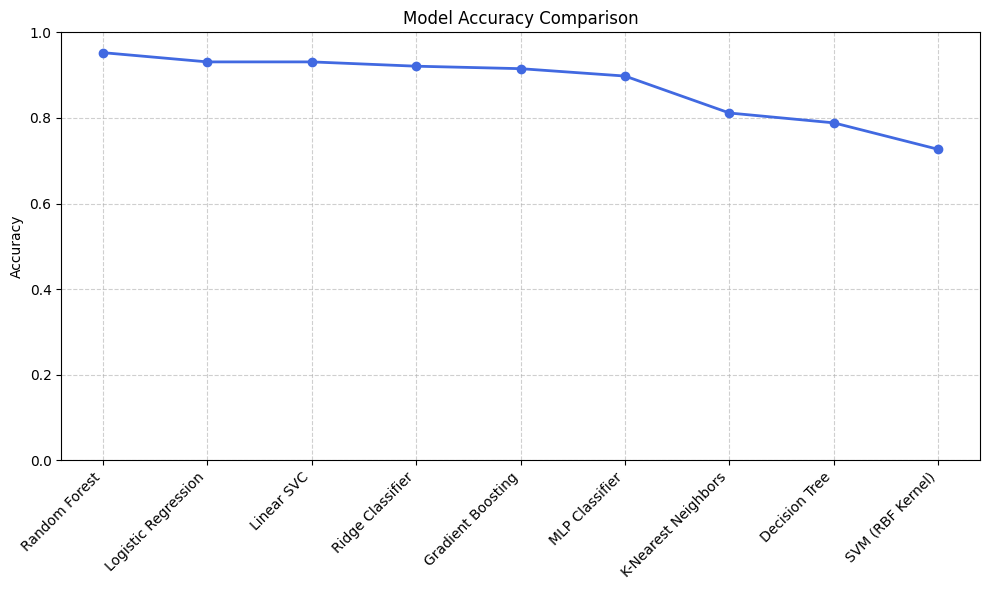

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(df["Model"], df["Accuracy"], marker='o', color='royalblue', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


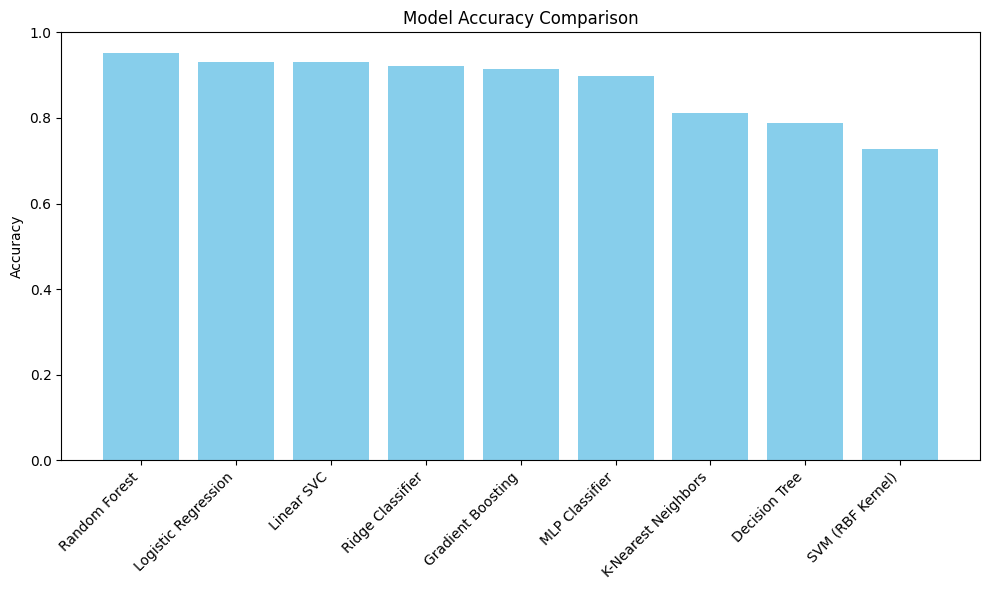

In [24]:
plt.figure(figsize=(10, 6))
plt.bar(df["Model"], df["Accuracy"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()


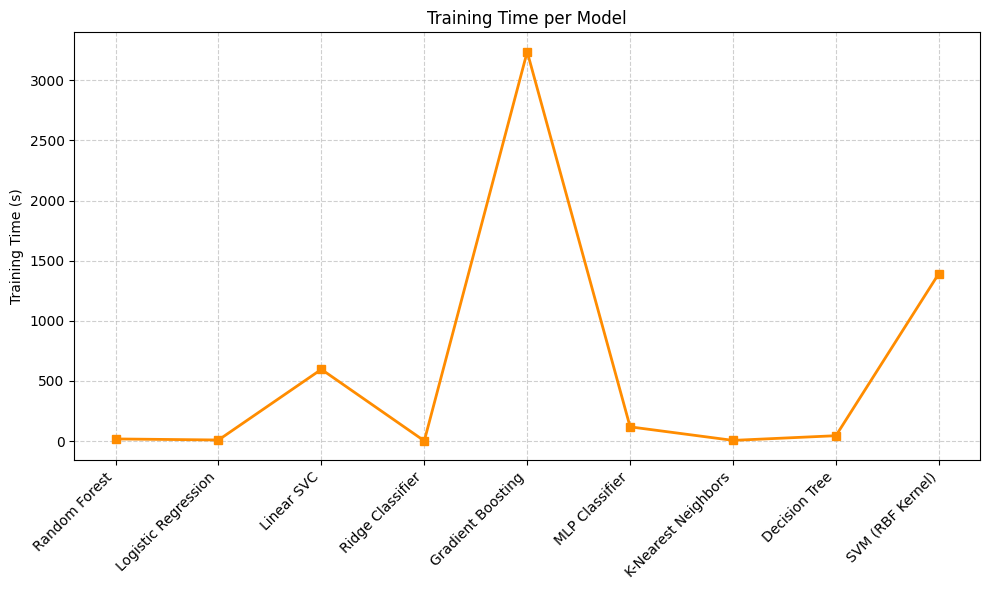

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(df["Model"], df["Time (s)"], marker='s', color='darkorange', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Training Time (s)")
plt.title("Training Time per Model")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


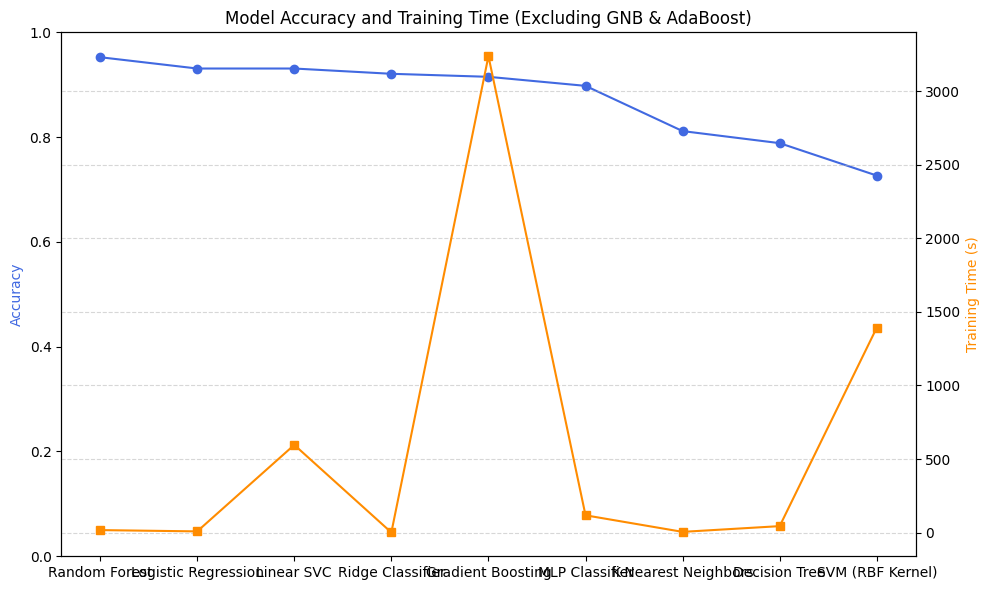

In [22]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()
ax1.plot(df["Model"], df["Accuracy"], color='royalblue', marker='o', label='Accuracy')
ax2.plot(df["Model"], df["Time (s)"], color='darkorange', marker='s', label='Time (s)')

ax1.set_ylabel('Accuracy', color='royalblue')
ax2.set_ylabel('Training Time (s)', color='darkorange')
ax1.set_ylim(0, 1)

plt.xticks(rotation=45, ha='right')
plt.title('Model Accuracy and Training Time (Excluding GNB & AdaBoost)')
plt.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()


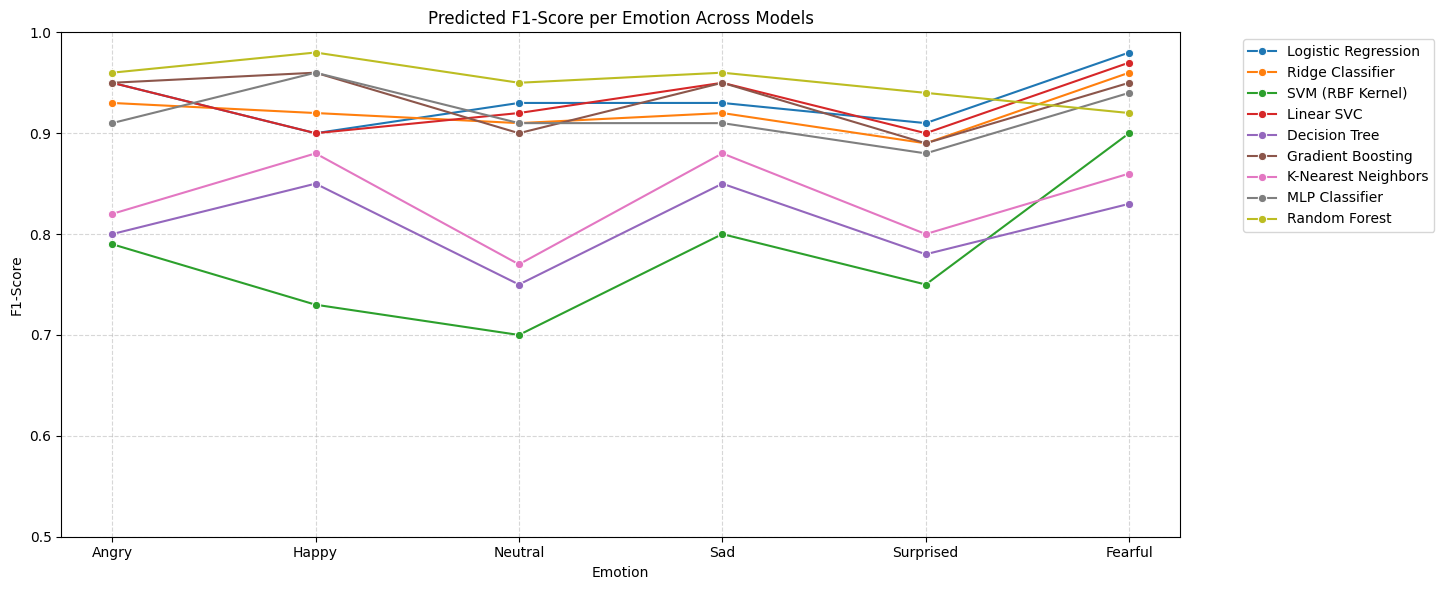

In [14]:
import sklearn
print(sklearn.__version__)


1.6.1


In [11]:
# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=180,class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=180,
                       random_state=42)

In [12]:
# Evaluate the model
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy of Random Forest Model: {accuracy * 100:.2f}%")


Accuracy of Random Forest Model: 95.25%


In [21]:
import joblib

# Save model
joblib.dump(rf_model, r'C:\Users\apder\Videos\best_random_forest_model.pkl')
joblib.dump(scaler, r'C:\Users\apder\Videos\standard_scaler.pkl')



['C:\\Users\\apder\\Videos\\standard_scaler.pkl']

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Angry       0.94      0.97      0.96      1270
     Fearful       1.00      0.89      0.94       246
       Happy       1.00      0.91      0.95       672
     Neutral       0.91      0.98      0.94      1385
         Sad       0.96      0.91      0.94       920
   Surprised       0.94      0.93      0.94       532

    accuracy                           0.95      5025
   macro avg       0.96      0.93      0.94      5025
weighted avg       0.95      0.95      0.95      5025



In [19]:
rf_model.feature_importances_

array([0.0003495 , 0.00035937, 0.00047141, ..., 0.        , 0.        ,
       0.        ])

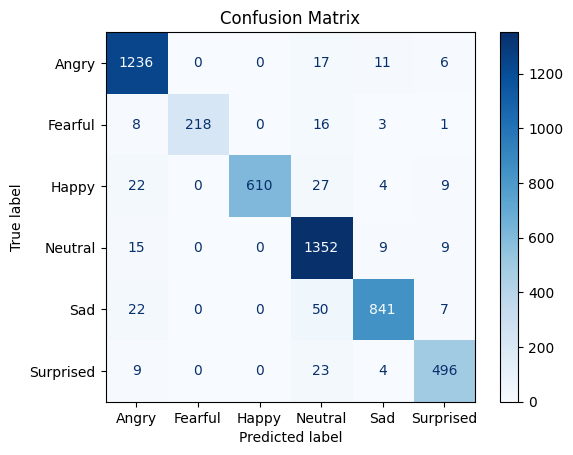

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [57]:
import librosa
import numpy as np

# Step 1: Load and extract features from the new audio file
real_audio_path = r"C:\Users\apder\Downloads\Angry Indian Ringtone (SMG4 RING RING RING SOUND)(MP3_160K).wav"  # Path to the new audio
features = get_features(real_audio_path)

if features is not None:
    # Step 2: Stack the features
    X_real = np.vstack(features).astype(np.float32)

    # Step 3: Apply the same scaler used during training
    X_real_scaled = scaler.transform(X_real)

    # Step 4: If PCA was used during training, apply it
    X_real_final = pca.transform(X_real_scaled)

    # Step 5: Predict emotions for each augmented version
    predictions = rf_model.predict(X_real_final)

    # Step 6: Output the most common prediction (majority vote)
    from collections import Counter
    final_prediction = Counter(predictions).most_common(1)[0][0]

    print(f"\nPredicted Emotion for the real audio: {final_prediction}")
    print(f"All predictions from augmentations: {predictions}")

else:
    print("Could not extract features from the real audio.")



Predicted Emotion for the real audio: Angry
All predictions from augmentations: ['Angry' 'Angry' 'Neutral' 'Neutral' 'Angry' 'Angry']


In [63]:
features.shape  

(6, 55585)